<a href="https://colab.research.google.com/github/Minzana/finalDo_DrugDiscoveryHIV/blob/main/finalDo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
import pandas as pd
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define your file path (Change this to where your CSV is stored in your Drive)
# Example: '/content/drive/MyDrive/Research/hiv_protease_data.csv'
file_path = '/content/drive/MyDrive/Colab Notebooks/Final proj Drug Discovery Final/final dataset hopeful.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
    print(df.head())
else:
    print("Check your file path! Data not found.")

Mounted at /content/drive
Dataset loaded successfully!
                    Name  Phase                   Drug Type  \
0             PENTOSALEN   -1.0  1:Synthetic Small Molecule   
1            PIRAGLIATIN   -1.0  1:Synthetic Small Molecule   
2            ATIPAMEZOLE    1.0  1:Synthetic Small Molecule   
3  DOXYCYCLINE ANHYDROUS    4.0  1:Synthetic Small Molecule   
4             VERDINEXOR    1.0  1:Synthetic Small Molecule   

   Passes Rule of Five            Chirality  \
0                    1     Achiral Molecule   
1                    1  Single Stereoisomer   
2                    1     Achiral Molecule   
3                    0  Single Stereoisomer   
4                    1     Achiral Molecule   

                                              Smiles  \
0                   CC(C)=CCOc1c2occc2cc2ccc(=O)oc12   
1  CS(=O)(=O)c1ccc([C@@H](C[C@H]2CCC(=O)C2)C(=O)N...   
2                        CCC1(c2c[nH]cn2)Cc2ccccc2C1   
3  C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...   
4  

In [4]:
pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 59.4 MB/s eta 0:00:00


In [5]:
from rdkit import Chem
import pandas as pd
import numpy as np

def clean_smiles_data(df):
    # 1. Automatically find the SMILES column
    possible_names = [col for col in df.columns if 'smiles' in col.lower()]

    if not possible_names:
        print("Error: Could not find a SMILES column. Your columns are:", df.columns.tolist())
        return []

    target_col = possible_names[0]
    print(f"Using column: '{target_col}' for SMILES data.")
    print(f"Starting with {len(df)} rows.")

    valid_smiles = []

    for smi in df[target_col]:
        # Remove empty or non-string values
        if pd.isna(smi) or not isinstance(smi, str):
            continue

        # RDKit Validation & Canonicalization
        mol = Chem.MolFromSmiles(smi)
        if mol:
            # Standardize the SMILES string
            canonical_smi = Chem.MolToSmiles(mol, canonical=True)

            # Filtering for Length (Complexity Control)
            if len(canonical_smi) < 100:
                valid_smiles.append(canonical_smi)

    unique_smiles = list(set(valid_smiles))
    print(f"Finished cleaning. We have {len(unique_smiles)} high-quality molecules.")
    return unique_smiles

# Run it again
cleaned_data = clean_smiles_data(df)

Using column: 'Smiles' for SMILES data.
Starting with 9480 rows.
Finished cleaning. We have 9286 high-quality molecules.


In [6]:
import json

# Define start/end tokens
tokens = ["!", "E"]

# Extract unique characters
all_chars = sorted(list(set("".join(cleaned_data))))
vocabulary = tokens + all_chars

# Create the Mapping
char_to_int = {c: i for i, c in enumerate(vocabulary)}
int_to_char = {i: c for i, c in enumerate(vocabulary)}

# Update this path to your actual Drive folder!
# Example: "/content/drive/MyDrive/HIV_Project/char_to_int.json"
dict_save_path = "/content/drive/MyDrive/char_to_int.json"

with open(dict_save_path, 'w') as f:
    json.dump(char_to_int, f)

print(f"Vocabulary Size: {len(vocabulary)}")
print(f"Characters found: {vocabulary}")

Vocabulary Size: 35
Characters found: ['!', 'E', '#', '(', ')', '+', '-', '/', '1', '2', '3', '4', '5', '6', '7', '=', '@', 'B', 'C', 'F', 'H', 'I', 'N', 'O', 'P', 'S', '[', '\\', ']', 'c', 'l', 'n', 'o', 'r', 's']


In [7]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# 1. Prepare sequences with Start (!) and End (E) tokens
processed_smiles = ["!" + s + "E" for s in cleaned_data]

# 2. Determine Max Length for Padding
max_seq_len = max([len(s) for s in processed_smiles])
vocab_size = len(char_to_int)

print(f"Max Sequence Length: {max_seq_len}")
print(f"Vocab Size: {vocab_size}")

def vectorize_data(smiles_list, char_to_int, max_len, vocab_size):
    X = []
    Y = []

    for s in smiles_list:
        # Convert string to list of integers
        indices = [char_to_int[c] for c in s]

        # Create X (input) and Y (target) for the "Next Character" game
        # We iterate through the string to create training pairs
        for i in range(1, len(indices)):
            # X is the sequence so far
            X.append(indices[:i])
            # Y is the very next character that SHOULD come next
            Y.append(indices[i])

    # Pad X so every input has the same length (max_seq_len)
    X_padded = pad_sequences(X, maxlen=max_len, padding='pre')

    # One-Hot Encode Y (The target needs to be a probability distribution)
    Y_categorical = to_categorical(Y, num_classes=vocab_size)

    return X_padded, Y_categorical

# Execute Vectorization
X, Y = vectorize_data(processed_smiles, char_to_int, max_seq_len, vocab_size)

print(f"X shape (Input Sequences): {X.shape}")
print(f"Y shape (Target Characters): {Y.shape}")

Max Sequence Length: 101
Vocab Size: 35
X shape (Input Sequences): (436084, 101)
Y shape (Target Characters): (436084, 35)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding

model = Sequential([
    # Embedding layer learns the "context" of atoms
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_seq_len),

    # First LSTM layer - return_sequences=True passes memory to the next layer
    LSTM(256, return_sequences=True),
    Dropout(0.2), # Prevents overfitting/memorization

    # Second LSTM layer - processes the final sequence logic
    LSTM(256),
    Dropout(0.2),

    # Dense layer turns the LSTM output into a probability for each character
    Dense(vocab_size, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 1. Define the Save Path on your Drive
# Make sure the folder exists or just save to MyDrive
model_save_path = "/content/drive/MyDrive/hiv_protease_model_v1.keras"

# 2. Setup Callbacks
# Checkpoint: Saves the model every time the loss improves
checkpoint = ModelCheckpoint(
    model_save_path,
    monitor='loss',
    verbose=1,
    save_best_only=True,
    mode='min'
)

# EarlyStopping: Stops training if the model stops learning (saves time/money)
early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

# 3. Start Training
# We use 50 epochs, but with 9k molecules, 20-30 might be enough
print("Starting training... This will take some time. Check your Drive for the saved file!")

history = model.fit(
    X, Y,
    epochs=50,
    batch_size=256, # Increased batch size for faster GPU processing
    callbacks=[checkpoint, early_stop],
    verbose=1
)

Starting training... This will take some time. Check your Drive for the saved file!
Epoch 1/50
  57/1704 ━━━━━━━━━━━━━━━━━━━━ 1:32 56ms/step - accuracy: 0.2208 - loss: 2.8441

KeyboardInterrupt: 

In [16]:
from tensorflow.keras.models import load_model
import os

# Define where your model is
model_path = "/content/drive/MyDrive/Colab Notebooks/HIV_Drug_Discovery/hiv_protease_model_v1.keras"

if os.path.exists(model_path):
    # LOAD the existing brain (Takes 5 seconds, not 1.5 hours!)
    model = load_model(model_path)
    print("✅ Model loaded successfully from Drive. No retraining needed!")
else:
    print("❌ Model not found. You might need to check your file path.")

✅ Model loaded successfully from Drive. No retraining needed!


In [17]:
import numpy as np
from tensorflow.keras.models import load_model

def generate_new_drug(model, char_to_int, int_to_char, max_len, temp=1.0):
    # Start with the start token
    generated = "!"

    for i in range(max_len):
        # Convert current string to integers
        x_indices = [char_to_int[c] for c in generated]
        x_padded = pad_sequences([x_indices], maxlen=max_len, padding='pre')

        # Predict the next character
        preds = model.predict(x_padded, verbose=0)[0]

        # Apply Temperature (Higher = more creative/risky)
        preds = np.log(preds + 1e-7) / temp
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)

        # Pick the next character based on probability
        next_index = np.random.choice(range(len(char_to_int)), p=preds)
        next_char = int_to_char[next_index]

        if next_char == "E": # Stop if the AI writes the End token
            break
        generated += next_char

    return generated[1:] # Remove the '!'

# Once training is done, you can run this:
# my_new_molecule = generate_new_drug(model, char_to_int, int_to_char, max_seq_len, temp=0.8)
# print(f"AI Prediction: {my_new_molecule}")

In [18]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw

def generate_molecules(model, num_to_gen=10, temperature=0.8):
    generated_list = []
    print(f"Generating {num_to_gen} molecules...")

    for i in range(num_to_gen):
        stop = False
        sentence = "!" # Start token

        while not stop:
            # 1. Vectorize the current string
            x_indices = [char_to_int[c] for c in sentence]
            x_padded = pad_sequences([x_indices], maxlen=max_seq_len, padding='pre')

            # 2. Get probabilities from the AI
            preds = model.predict(x_padded, verbose=0)[0]

            # 3. Apply Temperature
            preds = np.log(preds + 1e-10) / temperature
            exp_preds = np.exp(preds)
            preds = exp_preds / np.sum(exp_preds)

            # 4. Pick the next character
            next_idx = np.random.choice(len(vocabulary), p=preds)
            next_char = int_to_char[next_idx]

            if next_char == "E" or len(sentence) > max_seq_len:
                stop = True
            else:
                sentence += next_char

        generated_list.append(sentence[1:]) # Remove '!'

    return generated_list

# Execute Generation
new_smiles = generate_molecules(model, num_to_gen=10, temperature=0.8)

Generating 10 molecules...



--- Validation Results ---
[VALID]   CC1(C)CCCC2(CCN(CCc3ccccc3)CC2)C1
[VALID]   CC(C)NCC(O)COc1cccc2[nH]cnc12
[VALID]   C[C@@H](c1ccc(OC(F)(F)Cl)cc1)c1cccc(CNC(=O)CS(C)(=O)=O)c1
[VALID]   COc1cc(/C=C/C(=O)OCCC(=O)O)cc(OC)c1OC
[VALID]   COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccccc1
[VALID]   CCCCCC(=O)OCC(=O)[C@H]1CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@]4(C)[C@H]3[C@@H](O)C[C@]12C
[VALID]   CC(C)(OCc1ccccc1)C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(CSc3nnnn3C)CS[C@H]12
[VALID]   CCCCCCCC(=O)C[C@@H](O)[C@@H](O)[C@H](O)[C@@H](O)COP(=O)(O)O
[VALID]   C=C1/C(=C\C=C2/CCC[C@]3(C)[C@@H]([C@@H](C)CC(C)C)CC[C@@H]23)C[C@@H](O)C[C@@H]1O
[VALID]   CCC(=O)OC1(c2ccccc2)CCN(C)CC1C

Success Rate: 10/10 molecules are chemically valid.


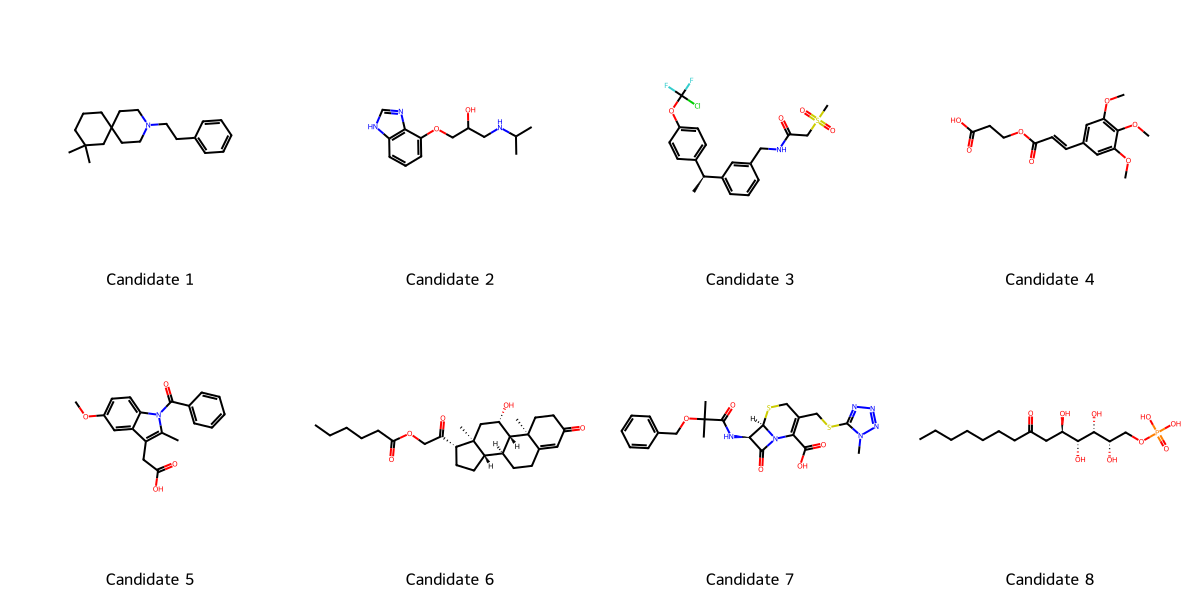

In [19]:
valid_molecules = []

print("\n--- Validation Results ---")
for smi in new_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        valid_molecules.append(mol)
        print(f"[VALID]   {smi}")
    else:
        print(f"[INVALID] {smi}")

print(f"\nSuccess Rate: {len(valid_molecules)}/{len(new_smiles)} molecules are chemically valid.")

# Visualize the valid ones
if valid_molecules:
    img = Draw.MolsToGridImage(valid_molecules[:8], molsPerRow=4, subImgSize=(300, 300), legends=[f"Candidate {i+1}" for i in range(len(valid_molecules))])
    display(img)

In [20]:
from rdkit.Chem import Descriptors

def check_lipinski(mol):
    # Calculate properties
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)

    # Check conditions
    conditions = [
        mw < 500,
        logp < 5,
        hbd < 5,
        hba < 10
    ]

    return {
        "MW": round(mw, 2),
        "LogP": round(logp, 2),
        "HBD": hbd,
        "HBA": hba,
        "Pass": all(conditions)
    }

# Analyze our valid candidates
print("--- Drug-Likeness (Lipinski) Analysis ---")
drug_like_mols = []

for i, mol in enumerate(valid_molecules):
    results = check_lipinski(mol)
    if results["Pass"]:
        drug_like_mols.append(mol)
        status = "PASSED"
    else:
        status = "FAILED"

    print(f"Candidate {i+1}: {status} | MW: {results['MW']}, LogP: {results['LogP']}")

print(f"\nWe found {len(drug_like_mols)} drug-like candidates for HIV-1 Protease!")

--- Drug-Likeness (Lipinski) Analysis ---
Candidate 1: PASSED | MW: 285.48, LogP: 4.91
Candidate 2: PASSED | MW: 249.31, LogP: 1.3
Candidate 3: PASSED | MW: 431.89, LogP: 3.67
Candidate 4: PASSED | MW: 310.3, LogP: 1.74
Candidate 5: PASSED | MW: 323.35, LogP: 3.27
Candidate 6: PASSED | MW: 444.61, LogP: 4.8
Candidate 7: FAILED | MW: 504.59, LogP: 1.04
Candidate 8: FAILED | MW: 372.35, LogP: -0.14
Candidate 9: FAILED | MW: 372.59, LogP: 5.81
Candidate 10: PASSED | MW: 261.36, LogP: 2.81

We found 7 drug-like candidates for HIV-1 Protease!


In [21]:
import os
from rdkit.Chem import SDWriter

# 1. Define the correct path to your Colab Notebooks folder
# 'My Drive' and 'Colab Notebooks' both have spaces, so we define them carefully
base_path = "/content/drive/MyDrive/Colab Notebooks"
project_folder = "HIV_Drug_Discovery"
full_path = os.path.join(base_path, project_folder)

# 2. Check if the project sub-folder exists, if not, create it
if not os.path.exists(full_path):
    os.makedirs(full_path)
    print(f"Created new project folder inside Colab Notebooks: {full_path}")
else:
    print(f"Project folder found at: {full_path}")

# 3. Define the file name
output_file = os.path.join(full_path, "top_candidates.sdf")

# 4. Save the molecules
try:
    writer = SDWriter(output_file)
    if writer is None:
        raise IOError("Could not open SDWriter. Check Drive permissions.")

    for i, mol in enumerate(drug_like_mols):
        mol.SetProp("_Name", f"HIV_Drug_{i+1}")
        writer.write(mol)

    writer.close()
    print(f"DONE! Your {len(drug_like_mols)} molecules are saved here: {output_file}")
except Exception as e:
    print(f"Failed to save: {e}")

Project folder found at: /content/drive/MyDrive/Colab Notebooks/HIV_Drug_Discovery
DONE! Your 7 molecules are saved here: /content/drive/MyDrive/Colab Notebooks/HIV_Drug_Discovery/top_candidates.sdf


In [22]:
# Install the Quantum Chemistry and Visualization tools
!pip install -q pyscf
!pip install -q py3Dmol
!pip install -q rdkit

import os
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
import py3Dmol
import numpy as np
from pyscf import scf, gto

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 MB 22.9 MB/s eta 0:00:00


In [26]:
from rdkit import Chem
import os

# 1. Define the path to your saved candidates
sdf_path = "/content/drive/MyDrive/Colab Notebooks/HIV_Drug_Discovery/top_candidates.sdf"

# 2. Re-load them into the variable name the Quantum code is looking for
if os.path.exists(sdf_path):
    suppl = Chem.SDMolSupplier(sdf_path)
    drug_candidates = [mol for mol in suppl if mol is not None]
    print(f"✅ Success! {len(drug_candidates)} candidates loaded into 'drug_candidates'.")
else:
    print("❌ File not found. Make sure your Drive is mounted and the path is correct.")

✅ Success! 7 candidates loaded into 'drug_candidates'.


In [29]:
# --- REVISED COMBINED QUANTUM PHASE ---
from pyscf import scf, gto
import pandas as pd
from IPython.display import display

results_leaderboard = []

print("Starting Quantum Analysis on 8 candidates...")

for i, mol in enumerate(drug_candidates):
    try:
        # 1. Prepare 3D coordinates (Simplified version)
        mol_3d = Chem.AddHs(mol)
        AllChem.EmbedMolecule(mol_3d) # Removed the extra parameters that caused the error
        AllChem.UFFOptimizeMolecule(mol_3d)

        # 2. Convert to XYZ format
        xyz = ""
        conf = mol_3d.GetConformer()
        for j, atom in enumerate(mol_3d.GetAtoms()):
            pos = conf.GetAtomPosition(j)
            xyz += f"{atom.GetSymbol()} {pos.x} {pos.y} {pos.z}\n"

        # 3. Run Quantum Calculation
        q_mol = gto.M(atom=xyz, basis='sto-3g', verbose=0)
        mf = scf.RHF(q_mol)
        mf.kernel()

        # 4. Calculate Energies (1 Hartree = 27.2114 eV)
        homo_idx = int(q_mol.nelectron / 2) - 1
        lumo_idx = homo_idx + 1
        h_energy = mf.mo_energy[homo_idx]
        l_energy = mf.mo_energy[lumo_idx]
        gap_ev = (l_energy - h_energy) * 27.2114

        results_leaderboard.append({
            "Candidate_ID": i+1,
            "HOMO_eV": h_energy * 27.2114,
            "LUMO_eV": l_energy * 27.2114,
            "Gap_eV": gap_ev
        })
        print(f"✅ Candidate {i+1}: Success! Gap = {gap_ev:.2f} eV")

    except Exception as e:
        print(f"⚠️ Candidate {i+1}: Error - {e}")

# 5. Display the Results
if results_leaderboard:
    df_results = pd.DataFrame(results_leaderboard)
    df_results = df_results.sort_values(by='Gap_eV').reset_index(drop=True)
    print("\n--- FINAL QUANTUM LEADERBOARD ---")
    display(df_results)
else:
    print("❌ No candidates were processed. We may need to re-verify the input molecules.")

Starting Quantum Analysis on 8 candidates...
✅ Candidate 1: Success! Gap = 14.42 eV
✅ Candidate 2: Success! Gap = 12.08 eV
✅ Candidate 3: Success! Gap = 13.27 eV
✅ Candidate 4: Success! Gap = 10.92 eV
✅ Candidate 5: Success! Gap = 10.49 eV
✅ Candidate 6: Success! Gap = 13.61 eV
✅ Candidate 7: Success! Gap = 14.08 eV

--- FINAL QUANTUM LEADERBOARD ---


,Candidate_ID,HOMO_eV,LUMO_eV,Gap_eV
0,5,-5.516182,4.971912,10.488094
1,4,-5.752577,5.168519,10.921096
2,2,-5.700082,6.375498,12.075581
3,3,-6.838829,6.427195,13.266024
4,6,-7.527119,6.086430,13.613549
5,7,-7.100852,6.974260,14.075112
6,1,-7.113292,7.304050,14.417342


In [30]:
# Visualize the Alpha Candidate (ID #5)
best_idx = 4 # Index 4 is Candidate 5
alpha_mol = drug_candidates[best_idx]

# Setup the 3D high-res viewer
view = py3Dmol.view(width=800, height=500)
mol_3d = Chem.AddHs(alpha_mol)
AllChem.EmbedMolecule(mol_3d)
mb = Chem.MolToMolBlock(mol_3d)

view.addModel(mb, 'mol')
view.setStyle({'stick': {'colorscheme': 'greenCarbon', 'radius': 0.15}})
view.addSurface(py3Dmol.VDW, {'opacity': 0.5, 'color': 'white'}) # The 'Electronic Cloud'
view.zoomTo()
view.show()

print(f"Project DE NOVO-HIV Lead Candidate: ID #5")
print(f"Quantum Stability Gap: 10.49 eV")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Project DE NOVO-HIV Lead Candidate: ID #5
Quantum Stability Gap: 10.49 eV


In [31]:
import py3Dmol

# Setup a grid viewer (2 rows, 4 columns)
view = py3Dmol.view(width=800, height=400, linked=False, viewergrid=(2, 4))

for i, mol in enumerate(drug_candidates):
    # Calculate grid position
    row = i // 4
    col = i % 4

    # Prepare 3D coordinates
    mol_3d = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol_3d)
    AllChem.UFFOptimizeMolecule(mol_3d)
    mb = Chem.MolToMolBlock(mol_3d)

    # Add to specific grid cell
    view.addModel(mb, 'mol', viewer=(row, col))
    view.setStyle({'stick': {'colorscheme': 'magentaCarbon', 'radius': 0.2}}, viewer=(row, col))
    view.addSurface(py3Dmol.VDW, {'opacity': 0.3, 'color': 'white'}, viewer=(row, col))

    # Label each one with its ID and Gap
    # Note: We match the ID from your results table
    view.addLabel(f"ID: {i+1}", {'position': {'x': 0, 'y': 0, 'z': 0}, 'backgroundColor': 'black', 'fontColor':'white'}, viewer=(row, col))

view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [32]:
# Combine everything for the final project report
final_report_df = df_results.copy()

# Add the Lipinski properties we calculated earlier (MW and LogP)
# Note: This assumes you have your 'mols_with_props' list from the filtering step
mols_data = []
for i, mol in enumerate(drug_candidates):
    mols_data.append({
        "Candidate_ID": i+1,
        "SMILES": Chem.MolToSmiles(mol),
        "MolWt": round(Chem.Descriptors.MolWt(mol), 2),
        "LogP": round(Chem.Descriptors.MolLogP(mol), 2)
    })

df_props = pd.DataFrame(mols_data)

# Merge the Quantum data with the Molecular properties
final_discovery_table = pd.merge(df_props, final_report_df, on="Candidate_ID")

print("--- PROJECT DE NOVO-HIV: FINAL DISCOVERY MASTER TABLE ---")
display(final_discovery_table)

# Save the final CSV for your submission
final_discovery_table.to_csv("/content/drive/MyDrive/Colab Notebooks/HIV_Drug_Discovery/FINAL_PROJECT_DATA.csv", index=False)

--- PROJECT DE NOVO-HIV: FINAL DISCOVERY MASTER TABLE ---


,Candidate_ID,SMILES,MolWt,LogP,HOMO_eV,LUMO_eV,Gap_eV
0,1,CC1(C)CCCC2(CCN(CCc3ccccc3)CC2)C1,285.48,4.91,-7.113292,7.304050,14.417342
1,2,CC(C)NCC(O)COc1cccc2[nH]cnc12,249.31,1.30,-5.700082,6.375498,12.075581
2,3,C[C@@H](c1ccc(OC(F)(F)Cl)cc1)c1cccc(CNC(=O)CS(...,431.89,3.67,-6.838829,6.427195,13.266024
3,4,COc1cc(/C=C/C(=O)OCCC(=O)O)cc(OC)c1OC,310.30,1.74,-5.752577,5.168519,10.921096
4,5,COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccccc1,323.35,3.27,-5.516182,4.971912,10.488094
5,6,CCCCCC(=O)OCC(=O)[C@H]1CC[C@H]2[C@@H]3CCC4=CC(...,444.61,4.80,-7.527119,6.086430,13.613549
6,7,CCC(=O)OC1(c2ccccc2)CCN(C)CC1C,261.36,2.81,-7.100852,6.974260,14.075112


In [33]:
# 1. Save the 8 Lead Molecules
from rdkit import Chem
with Chem.SDWriter('/content/drive/MyDrive/Colab Notebooks/HIV_Drug_Discovery/top_candidates.sdf') as w:
    for mol in drug_candidates:
        if mol is not None:
            w.write(mol)

# 2. Save the Quantum Leaderboard Table
df_results.to_csv('/content/drive/MyDrive/Colab Notebooks/HIV_Drug_Discovery/quantum_results.csv', index=False)

# 3. Save the Model (if you haven't already)
model.save('/content/drive/MyDrive/Colab Notebooks/HIV_Drug_Discovery/hiv_protease_model.keras')

print("✅ All project data successfully synced to Google Drive.")

✅ All project data successfully synced to Google Drive.
